## Ejemplo KMeans
<div style="border-style:groove;border-width:thin;padding:10px">
Vamos a ver el primer ejemplo de esta técnica de clustering. Para ello vamos a usar el dataset de las flores pero sin las etiquetas del tipo de flor. Recordamos que este algoritmo agrupa los datos por similitudes teniendo en cuenta el número de clusters o grupos que le pasamos nosotros inicialmente. 
    </div>

<div style="border-style:groove;border-width:thin;padding:10px">
Lo primero que vamos a hacer es importar los datos del dataset de las flores (iris). Recordamos un poco como era.
    </div>

In [9]:
import numpy as np
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

iris = datasets.load_iris()
print(type(iris))
print(iris)
print(iris.DESCR)

<class 'sklearn.utils._bunch.Bunch'>
{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1

In [10]:
flores = pd.DataFrame()
flores['tipo_flor'] = iris['target']
flores['sepal_length'] = iris['data'][:,0]
flores['sepal_width'] = iris['data'][:,1]
flores['petal_length'] = iris['data'][:,2]
flores['petal_width'] = iris['data'][:,3]
print(flores.head())

flores.corr()

   tipo_flor  sepal_length  sepal_width  petal_length  petal_width
0          0           5.1          3.5           1.4          0.2
1          0           4.9          3.0           1.4          0.2
2          0           4.7          3.2           1.3          0.2
3          0           4.6          3.1           1.5          0.2
4          0           5.0          3.6           1.4          0.2


,tipo_flor,sepal_length,sepal_width,petal_length,petal_width
tipo_flor,1.000000,0.782561,-0.426658,0.949035,0.956547
sepal_length,0.782561,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.426658,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.949035,0.871754,-0.428440,1.000000,0.962865
petal_width,0.956547,0.817941,-0.366126,0.962865,1.000000


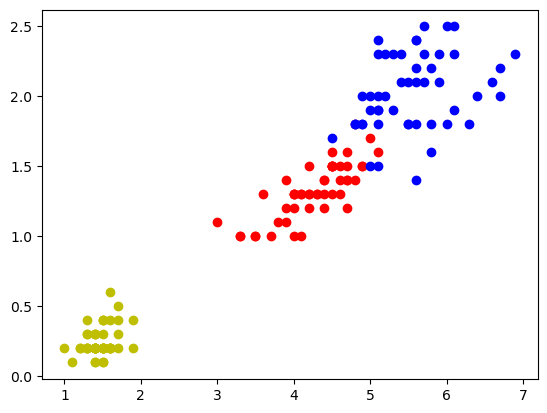

In [11]:
plt.scatter(flores.loc[flores['tipo_flor']==0]['petal_length'],flores.loc[flores['tipo_flor']==0]['petal_width'],color='y')
plt.scatter(flores.loc[flores['tipo_flor']==1]['petal_length'],flores.loc[flores['tipo_flor']==1]['petal_width'],color='r')
plt.scatter(flores.loc[flores['tipo_flor']==2]['petal_length'],flores.loc[flores['tipo_flor']==2]['petal_width'],color='b')

plt.show()

In [12]:
X = flores[['petal_length','petal_width']]
#y = flores['tipo_flor'].to_list()

<div style="border-style:groove;border-width:thin;padding:10px">
1. Importa el KMeans del paquete cluster de sklearn y crea el objeto usando el parámetro n_clusters=3. Por suerte en este ejercicio sabemos que hay 3 tipos de flores. Ahora entrena y etiqueta cada dato de entrada de X con el método fit_predict (guarda el resultado de este método en una variable llamada y_pred).
</div>

In [ ]:
# Importando librerias de KMeans
from sklearn.cluster import KMeans

# Creando el modelo de KMeans con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# Entrenando el modelo
y_pred = kmeans.fit_predict(X)

# Obteniendo las etiquetas despues de haber hecho el fit_predict
labels = kmeans.labels_

# Después de obtener las etiquetas, agrega al DataFrame
flores['cluster'] = labels
print(flores.head())

[[5.59583333 2.0375    ]
 [1.462      0.246     ]
 [4.26923077 1.34230769]]
   tipo_flor  sepal_length  sepal_width  petal_length  petal_width  cluster
0          0           5.1          3.5           1.4          0.2        1
1          0           4.9          3.0           1.4          0.2        1
2          0           4.7          3.2           1.3          0.2        1
3          0           4.6          3.1           1.5          0.2        1
4          0           5.0          3.6           1.4          0.2        1


<div style="border-style:groove;border-width:thin;padding:10px">
2. Mete el atributo cluster_centers_ en una variable y pinta con scatter los centros para ver que tal han quedado ubicados.
</div>

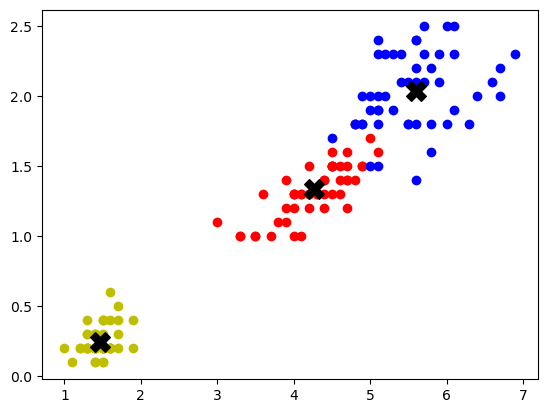

In [14]:
plt.scatter(flores.loc[flores['tipo_flor']==0]['petal_length'],flores.loc[flores['tipo_flor']==0]['petal_width'],color='y')
plt.scatter(flores.loc[flores['tipo_flor']==1]['petal_length'],flores.loc[flores['tipo_flor']==1]['petal_width'],color='r')
plt.scatter(flores.loc[flores['tipo_flor']==2]['petal_length'],flores.loc[flores['tipo_flor']==2]['petal_width'],color='b')


# Metiendo el atributo cluster_centers_ en una variable
centers = kmeans.cluster_centers_

# Pintando el gráfico con los centros
plt.scatter(centers[:, 0], centers[:, 1], color='k', marker='X', s=200, label='Centroides')

<div style="border-style:groove;border-width:thin;padding:10px">
3. Muestra y_pred. Son las etiquetas que ha puesto a cada dato. Vuelve a pintar los datos (esta vez todos en un mismo scatter, sin discriminar por etiqueta) y usa el parámetro c=y_pred para que les pinte de colores en función de la predicción de clase que ha hecho. ¿Se ha equivocado mucho?
    </div>

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0
 0 0]


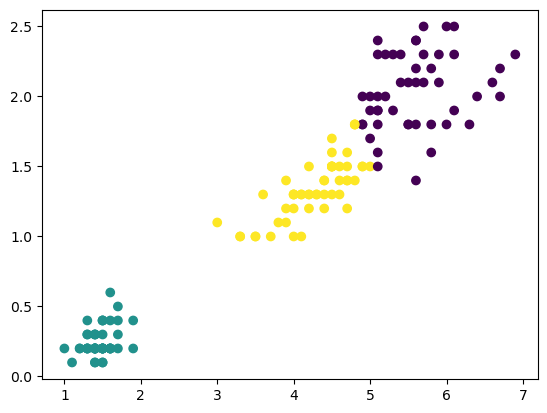

In [16]:
# Muestra y_pred
print(y_pred)

# Pintando los datos (en un mismo scatter sin discriminar por etiqueta)
plt.scatter(X["petal_length"], X["petal_width"], c=y_pred, cmap='viridis')

<div style="border-style:groove;border-width:thin;padding:10px">
Date cuenta de que el sistema que hemos hecho no tiene ni idea de que clase es cada flor... solo las ha dividido en 3 grupos, pero no sabe como se llaman las etiquetas. También hay que darse cuenta de que sabemos inicialmente que hay 3 grupos.
    </div>

<div style="border-style:groove;border-width:thin;padding:10px">
4. Ahora cambia los parámetros de KMeans. Pon init='random'm dale n_clusters=4, n_init=1 para que lo haga una sola vez y vete cambiando el random_state. Pinta los centros como hicimos antes.
    </div>

   tipo_flor  sepal_length  sepal_width  petal_length  petal_width  cluster
0          0           5.1          3.5           1.4          0.2        1
1          0           4.9          3.0           1.4          0.2        1
2          0           4.7          3.2           1.3          0.2        1
3          0           4.6          3.1           1.5          0.2        1
4          0           5.0          3.6           1.4          0.2        1
-19.48300089968511


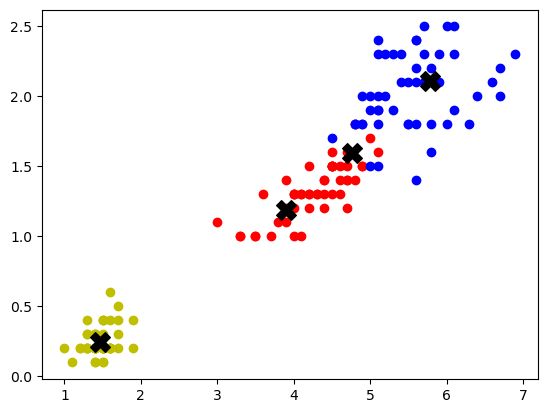

In [ ]:
# Importando librerias de KMeans
from sklearn.cluster import KMeans

# Creando el modelo de KMeans con 3 clusters
kmeans = KMeans(n_clusters=4, random_state=42)

# Entrenando el modelo
y_pred = kmeans.fit_predict(X)

# Obteniendo las etiquetas despues de haber hecho el fit_predict
labels = kmeans.labels_

# Después de obtener las etiquetas, agrega al DataFrame
flores['cluster'] = labels
print(flores.head())

# Mostrando los valores segun el tipo de flor
plt.scatter(flores.loc[flores['tipo_flor']==0]['petal_length'],flores.loc[flores['tipo_flor']==0]['petal_width'],color='y')
plt.scatter(flores.loc[flores['tipo_flor']==1]['petal_length'],flores.loc[flores['tipo_flor']==1]['petal_width'],color='r')
plt.scatter(flores.loc[flores['tipo_flor']==2]['petal_length'],flores.loc[flores['tipo_flor']==2]['petal_width'],color='b')

# Metiendo el atributo cluster_centers_ en una variable
centers = kmeans.cluster_centers_

# Pintando el gráfico con los centros
x, y = centers.T
plt.scatter(x, y, color='k', marker='X', s=200, label='Centroides')

# Esto mide la suma de las distancias al cuadrado de cada punto a su centroide mas cercano. Es decir, cuanto menor sea el valor, mejor se ha agrupado los datos.
# Por ejemplo -30 es mejor que -20.
#print(kmeans.score(X))